# GloVe Forward Pass

## Author: Dr Partha Majumdar
#### ORC-ID: 0009-0002-7375-8034

In [16]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=6, suppress=True)

# STEP 1: Define corpus

In [17]:
sentence = "I like orange juice and eat eggs daily"
tokens = sentence.split()

vocabulary = list(dict.fromkeys(tokens))   # preserve order
V = len(vocabulary)                        # vocabulary size
N = 3                                      # embedding dimension

word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for i, word in enumerate(vocabulary)}

print("STEP 1: Vocabulary")
print("Sentence:", sentence)
print("Tokens:", tokens)
print("Vocabulary:", vocabulary)
print("Vocabulary size V =", V)
print("Embedding dimension N =", N)

STEP 1: Vocabulary
Sentence: I like orange juice and eat eggs daily
Tokens: ['I', 'like', 'orange', 'juice', 'and', 'eat', 'eggs', 'daily']
Vocabulary: ['I', 'like', 'orange', 'juice', 'and', 'eat', 'eggs', 'daily']
Vocabulary size V = 8
Embedding dimension N = 3


# STEP 2: Build co-occurrence matrix X

In [18]:
def build_cooccurrence_matrix(tokens, word_to_index, window_size=2):
    """
    Build a symmetric word-word co-occurrence matrix.
    A simple inverse-distance weighting is used:
        contribution = 1 / distance
    """
    V = len(word_to_index)
    X = np.zeros((V, V), dtype=np.float64)

    for center_pos, center_word in enumerate(tokens):
        center_idx = word_to_index[center_word]

        start = max(0, center_pos - window_size)
        end = min(len(tokens), center_pos + window_size + 1)

        for context_pos in range(start, end):
            if context_pos == center_pos:
                continue

            context_word = tokens[context_pos]
            context_idx = word_to_index[context_word]

            distance = abs(center_pos - context_pos)
            contribution = 1.0 / distance

            X[center_idx, context_idx] += contribution

    return X

window_size = 2
X = build_cooccurrence_matrix(tokens, word_to_index, window_size=window_size)

print("\nSTEP 2: Co-occurrence Matrix X")
cooc_df = pd.DataFrame(X, index=vocabulary, columns=vocabulary)
print(cooc_df)


STEP 2: Co-occurrence Matrix X
          I  like  orange  juice  and  eat  eggs  daily
I       0.0   1.0     0.5    0.0  0.0  0.0   0.0    0.0
like    1.0   0.0     1.0    0.5  0.0  0.0   0.0    0.0
orange  0.5   1.0     0.0    1.0  0.5  0.0   0.0    0.0
juice   0.0   0.5     1.0    0.0  1.0  0.5   0.0    0.0
and     0.0   0.0     0.5    1.0  0.0  1.0   0.5    0.0
eat     0.0   0.0     0.0    0.5  1.0  0.0   1.0    0.5
eggs    0.0   0.0     0.0    0.0  0.5  1.0   0.0    1.0
daily   0.0   0.0     0.0    0.0  0.0  0.5   1.0    0.0


The co-occurrence matrix X captures how frequently words appear near each other within a fixed window—in this case, a window size of 2—with closer words contributing more strongly through inverse-distance weighting. Each row represents a “target” word and each column represents a “context” word, so an entry like X_{\text{orange, juice}} = 1.0 means that “juice” appears immediately next to “orange” (distance = 1), while X_{\text{orange, I}} = 0.5 reflects that “I” appears two positions away (distance = 2, hence contribution 1/2). The matrix is effectively symmetric because co-occurrence is counted in both directions as the window slides across the sentence. Words that never appear within the specified window of each other have a value of 0, indicating no direct contextual relationship under this definition. Overall, this matrix transforms the linear sentence into a structured representation of global word relationships, which GloVe later uses to learn embeddings by approximating the logarithm of these co-occurrence values.

# STEP 3: Select one GloVe training pair (i, j)

Example:

   target word   i = "orange"

   context word  j = "juice"

We will compute one forward pass for this pair only.


In [19]:
target_word = "orange"
context_word = "juice"

i = word_to_index[target_word]
j = word_to_index[context_word]

x_ij = X[i, j]

print("\nSTEP 3: Selected Training Pair")
print("Target word  (i) =", target_word, "| index =", i)
print("Context word (j) =", context_word, "| index =", j)
print("Co-occurrence X_ij =", x_ij)


STEP 3: Selected Training Pair
Target word  (i) = orange | index = 2
Context word (j) = juice | index = 3
Co-occurrence X_ij = 1.0


# STEP 4: Initialise GloVe parameters

 GloVe has:

   W       : word vectors          shape (V, N)

   W_tilde : context vectors       shape (V, N)

   b       : word biases           shape (V,)

   b_tilde : context biases        shape (V,)

In [20]:
np.random.seed(42)

W = np.random.randn(V, N) * 0.01
W_tilde = np.random.randn(V, N) * 0.01
b = np.random.randn(V) * 0.01
b_tilde = np.random.randn(V) * 0.01

print("\nSTEP 4: Initial GloVe Parameters")
print("W shape       =", W.shape, " (word vectors)")
print("W_tilde shape =", W_tilde.shape, " (context vectors)")
print("b shape       =", b.shape, " (word biases)")
print("b_tilde shape =", b_tilde.shape, " (context biases)")

print("\nWord vector matrix W")
print(pd.DataFrame(W, index=vocabulary, columns=[f"e{k+1}" for k in range(N)]))

print("\nContext vector matrix W_tilde")
print(pd.DataFrame(W_tilde, index=vocabulary, columns=[f"e{k+1}" for k in range(N)]))

print("\nWord bias vector b")
print(pd.DataFrame({"bias": b}, index=vocabulary))

print("\nContext bias vector b_tilde")
print(pd.DataFrame({"bias": b_tilde}, index=vocabulary))


STEP 4: Initial GloVe Parameters
W shape       = (8, 3)  (word vectors)
W_tilde shape = (8, 3)  (context vectors)
b shape       = (8,)  (word biases)
b_tilde shape = (8,)  (context biases)

Word vector matrix W
              e1        e2        e3
I       0.004967 -0.001383  0.006477
like    0.015230 -0.002342 -0.002341
orange  0.015792  0.007674 -0.004695
juice   0.005426 -0.004634 -0.004657
and     0.002420 -0.019133 -0.017249
eat    -0.005623 -0.010128  0.003142
eggs   -0.009080 -0.014123  0.014656
daily  -0.002258  0.000675 -0.014247

Context vector matrix W_tilde
              e1        e2        e3
I      -0.005444  0.001109 -0.011510
like    0.003757 -0.006006 -0.002917
orange -0.006017  0.018523 -0.000135
juice  -0.010577  0.008225 -0.012208
and     0.002089 -0.019597 -0.013282
eat     0.001969  0.007385  0.001714
eggs   -0.001156 -0.003011 -0.014785
daily  -0.007198 -0.004606  0.010571

Word bias vector b
            bias
I       0.003436
like   -0.017630
orange  0.003241
jui

# STEP 5: Define GloVe weighting function f(x)

 Standard form:

   f(x) = (x / x_max)^alpha   if x < x_max

   f(x) = 1                   otherwise


 Also:

   f(0) = 0


In [21]:
def glove_weight(x, x_max=100, alpha=0.75):
    if x == 0:
        return 0.0
    if x < x_max:
        return (x / x_max) ** alpha
    return 1.0

x_max = 100
alpha = 0.75

f_xij = glove_weight(x_ij, x_max=x_max, alpha=alpha)

print("\nSTEP 5: Weighting Function")
print("x_max =", x_max)
print("alpha =", alpha)
print("f(X_ij) =", f_xij)


STEP 5: Weighting Function
x_max = 100
alpha = 0.75
f(X_ij) = 0.03162277660168379


# STEP 6: Lookup vectors and biases for the selected pair

In [22]:
w_i = W[i]                 # word vector for target word
w_tilde_j = W_tilde[j]     # context vector for context word
b_i = b[i]                 # bias for target word
b_tilde_j = b_tilde[j]     # bias for context word

print("\nSTEP 6: Lookup Parameters for Selected Pair")
print(f"w_i        ({target_word}) =", w_i)
print(f"w_tilde_j  ({context_word}) =", w_tilde_j)
print(f"b_i        ({target_word}) =", b_i)
print(f"b_tilde_j  ({context_word}) =", b_tilde_j)


STEP 6: Lookup Parameters for Selected Pair
w_i        (orange) = [ 0.015792  0.007674 -0.004695]
w_tilde_j  (juice) = [-0.010577  0.008225 -0.012208]
b_i        (orange) = 0.00324083969394795
b_tilde_j  (juice) = 0.009755451271223592


# STEP 7: Compute dot product term

In [23]:
dot_product = np.dot(w_i, w_tilde_j)

print("\nSTEP 7: Dot Product")
print("w_i . w_tilde_j =", dot_product)


STEP 7: Dot Product
w_i . w_tilde_j = -4.659462993806404e-05


# STEP 8: Compute GloVe prediction

 GloVe tries to make:

   w_i^T w_tilde_j + b_i + b_tilde_j  ≈  log(X_ij)


 This is not a softmax probability.

 It is a scalar regression target.


In [24]:
prediction = dot_product + b_i + b_tilde_j
log_xij = np.log(x_ij)

print("\nSTEP 8: GloVe Scalar Prediction")
print("Prediction = w_i . w_tilde_j + b_i + b_tilde_j =", prediction)
print("Target     = log(X_ij) =", log_xij)


STEP 8: GloVe Scalar Prediction
Prediction = w_i . w_tilde_j + b_i + b_tilde_j = 0.012949696335233478
Target     = log(X_ij) = 0.0


# STEP 9: Compute residual error

In [25]:
residual = prediction - log_xij

print("\nSTEP 9: Residual Error")
print("Residual = Prediction - log(X_ij) =", residual)


STEP 9: Residual Error
Residual = Prediction - log(X_ij) = 0.012949696335233478


# STEP 10: Compute weighted GloVe loss for this one pair

 Single-pair GloVe loss:

   J_ij = f(X_ij) * (w_i^T w_tilde_j + b_i + b_tilde_j - log(X_ij))^2


In [26]:
pair_loss = f_xij * (residual ** 2)

print("\nSTEP 10: Single-Pair GloVe Loss")
print("J_ij =", pair_loss)


STEP 10: Single-Pair GloVe Loss
J_ij = 5.3029699854322805e-06


# STEP 11: Compact summary table

In [27]:
summary_df = pd.DataFrame({
    "Quantity": [
        "Target word i",
        "Context word j",
        "X_ij",
        "log(X_ij)",
        "f(X_ij)",
        "w_i . w_tilde_j",
        "b_i",
        "b_tilde_j",
        "Prediction",
        "Residual",
        "Pair Loss J_ij"
    ],
    "Value": [
        target_word,
        context_word,
        x_ij,
        log_xij,
        f_xij,
        dot_product,
        b_i,
        b_tilde_j,
        prediction,
        residual,
        pair_loss
    ]
})

print("\nSTEP 11: Final Summary")
print(summary_df)


STEP 11: Final Summary
           Quantity     Value
0     Target word i    orange
1    Context word j     juice
2              X_ij       1.0
3         log(X_ij)       0.0
4           f(X_ij)  0.031623
5   w_i . w_tilde_j -0.000047
6               b_i  0.003241
7         b_tilde_j  0.009755
8        Prediction   0.01295
9          Residual   0.01295
10   Pair Loss J_ij  0.000005


In [28]:
# ============================================================
# STEP 12: Optional interpretation
# ============================================================
print("\nSTEP 12: Interpretation")
print("GloVe does not produce a probability distribution in a forward pass.")
print("Instead, it produces a scalar prediction that tries to match log(X_ij).")
print("The weighting function controls how strongly this pair contributes to the loss.")
print("If prediction is close to log(X_ij), the loss becomes small.")


STEP 12: Interpretation
GloVe does not produce a probability distribution in a forward pass.
Instead, it produces a scalar prediction that tries to match log(X_ij).
The weighting function controls how strongly this pair contributes to the loss.
If prediction is close to log(X_ij), the loss becomes small.


# Neural Network Visualisation

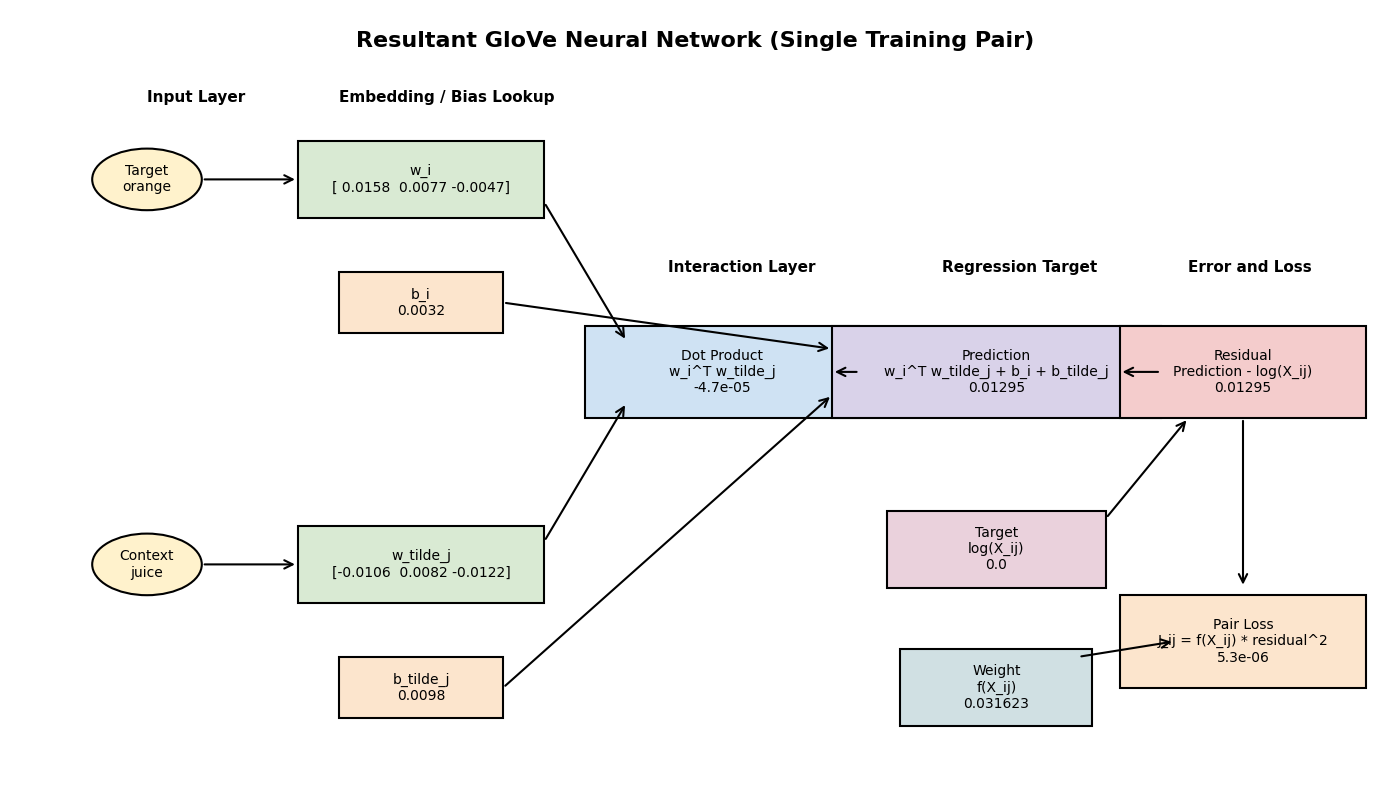

In [29]:
# ============================================================
# STEP 13: Visualise the resultant GloVe neural network
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def draw_node(x, y, text, radius=0.04, fontsize=10, fc="#f5f5f5", ec="black"):
    circle = Circle((x, y), radius, facecolor=fc, edgecolor=ec, lw=1.5)
    ax.add_patch(circle)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)

def draw_box(x, y, text, width=0.14, height=0.07, fontsize=10, fc="#eef5ff", ec="black"):
    rect = plt.Rectangle((x - width/2, y - height/2), width, height,
                         facecolor=fc, edgecolor=ec, lw=1.5)
    ax.add_patch(rect)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)

def draw_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle="->", mutation_scale=15, lw=1.5)
    ax.add_patch(arrow)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------
ax.text(0.5, 0.96, "Resultant GloVe Neural Network (Single Training Pair)",
        ha="center", va="center", fontsize=16, fontweight="bold")

# ------------------------------------------------------------
# Input words
# ------------------------------------------------------------
draw_node(0.10, 0.78, f"Target\n{target_word}", fc="#fff2cc")
draw_node(0.10, 0.28, f"Context\n{context_word}", fc="#fff2cc")

# ------------------------------------------------------------
# Word and context vectors
# ------------------------------------------------------------
draw_box(0.30, 0.78, f"w_i\n{np.round(w_i, 4)}", width=0.18, height=0.10, fc="#d9ead3")
draw_box(0.30, 0.28, f"w_tilde_j\n{np.round(w_tilde_j, 4)}", width=0.18, height=0.10, fc="#d9ead3")

draw_arrow(0.14, 0.78, 0.21, 0.78)
draw_arrow(0.14, 0.28, 0.21, 0.28)

# ------------------------------------------------------------
# Bias terms
# ------------------------------------------------------------
draw_box(0.30, 0.62, f"b_i\n{round(float(b_i), 4)}", width=0.12, height=0.08, fc="#fce5cd")
draw_box(0.30, 0.12, f"b_tilde_j\n{round(float(b_tilde_j), 4)}", width=0.12, height=0.08, fc="#fce5cd")

# ------------------------------------------------------------
# Dot product
# ------------------------------------------------------------
draw_box(0.52, 0.53, f"Dot Product\nw_i^T w_tilde_j\n{round(float(dot_product), 6)}",
         width=0.20, height=0.12, fc="#cfe2f3")

draw_arrow(0.39, 0.75, 0.45, 0.57)
draw_arrow(0.39, 0.31, 0.45, 0.49)

# ------------------------------------------------------------
# Prediction node
# ------------------------------------------------------------
draw_box(0.72, 0.53,
         f"Prediction\nw_i^T w_tilde_j + b_i + b_tilde_j\n{round(float(prediction), 6)}",
         width=0.24, height=0.12, fc="#d9d2e9")

draw_arrow(0.62, 0.53, 0.60, 0.53)
draw_arrow(0.36, 0.62, 0.60, 0.56)
draw_arrow(0.36, 0.12, 0.60, 0.50)

# ------------------------------------------------------------
# Target log(X_ij)
# ------------------------------------------------------------
draw_box(0.72, 0.30,
         f"Target\nlog(X_ij)\n{round(float(log_xij), 6)}",
         width=0.16, height=0.10, fc="#ead1dc")

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------
draw_box(0.90, 0.53,
         f"Residual\nPrediction - log(X_ij)\n{round(float(residual), 6)}",
         width=0.18, height=0.12, fc="#f4cccc")

draw_arrow(0.84, 0.53, 0.81, 0.53)
draw_arrow(0.80, 0.34, 0.86, 0.47)

# ------------------------------------------------------------
# Weighting function and loss
# ------------------------------------------------------------
draw_box(0.72, 0.12,
         f"Weight\nf(X_ij)\n{round(float(f_xij), 6)}",
         width=0.14, height=0.10, fc="#d0e0e3")

draw_box(0.90, 0.18,
         f"Pair Loss\nJ_ij = f(X_ij) * residual^2\n{round(float(pair_loss), 8)}",
         width=0.18, height=0.12, fc="#fce5cd")

draw_arrow(0.78, 0.16, 0.85, 0.18)
draw_arrow(0.90, 0.47, 0.90, 0.25)

# ------------------------------------------------------------
# Optional annotations
# ------------------------------------------------------------
ax.text(0.10, 0.88, "Input Layer", fontsize=11, fontweight="bold")
ax.text(0.24, 0.88, "Embedding / Bias Lookup", fontsize=11, fontweight="bold")
ax.text(0.48, 0.66, "Interaction Layer", fontsize=11, fontweight="bold")
ax.text(0.68, 0.66, "Regression Target", fontsize=11, fontweight="bold")
ax.text(0.86, 0.66, "Error and Loss", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()